<a href="https://colab.research.google.com/github/SilasDetering/SilasBA/blob/main/Triangulationsgraphen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import numpy as np

# Google Drive mounten
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Benutzer in -X Richtung


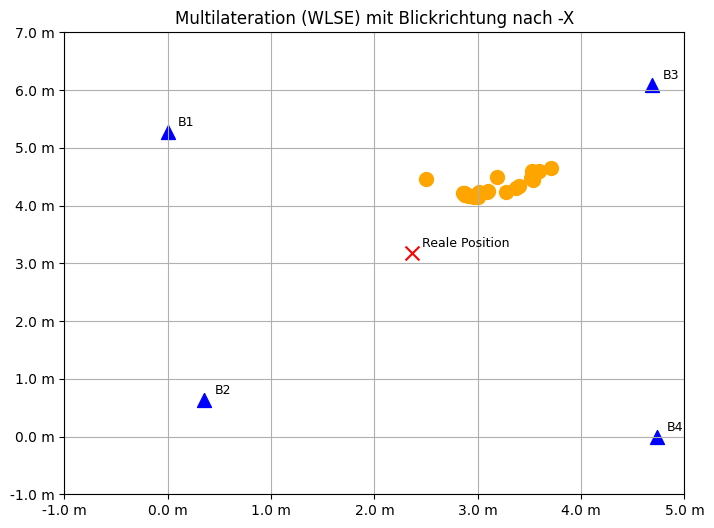

MSE for WLSE: 1.992 m


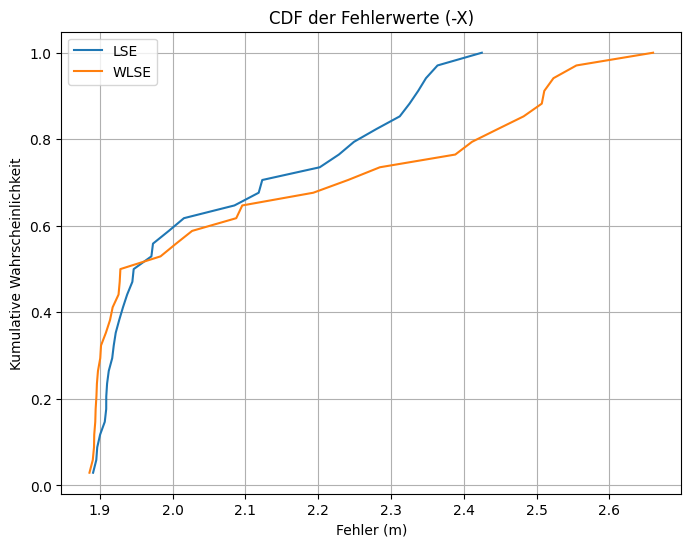

Benutzer in +X Richtung


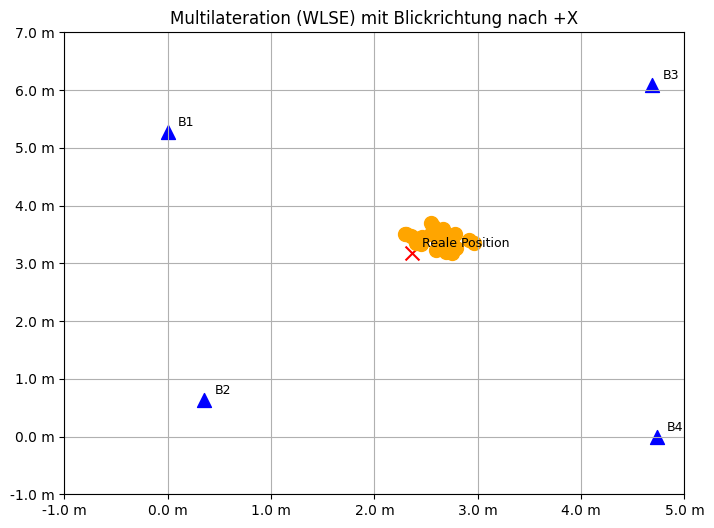

MSE for WLSE: 0.159 m


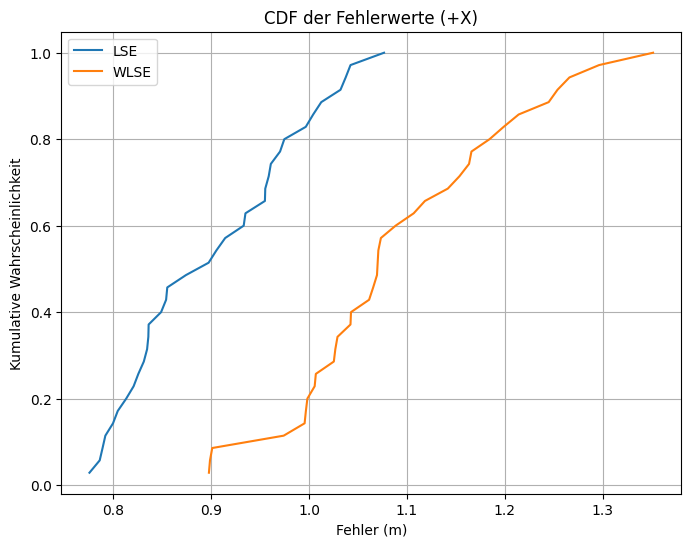

Benutzer in -Y Richtung


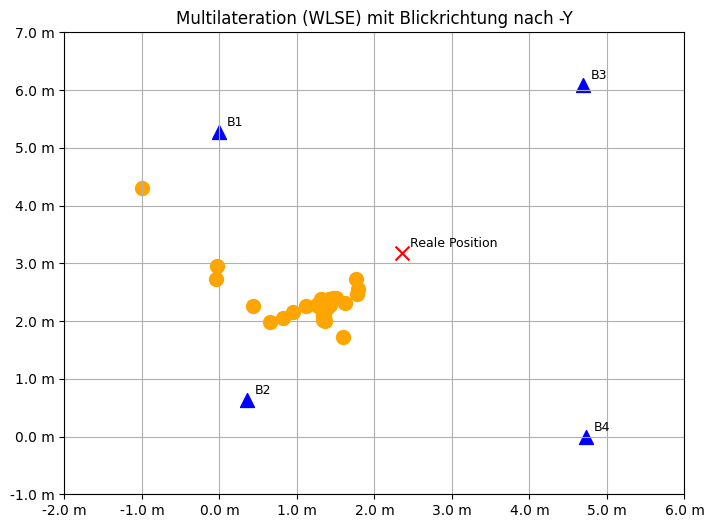

MSE for WLSE: 2.609 m


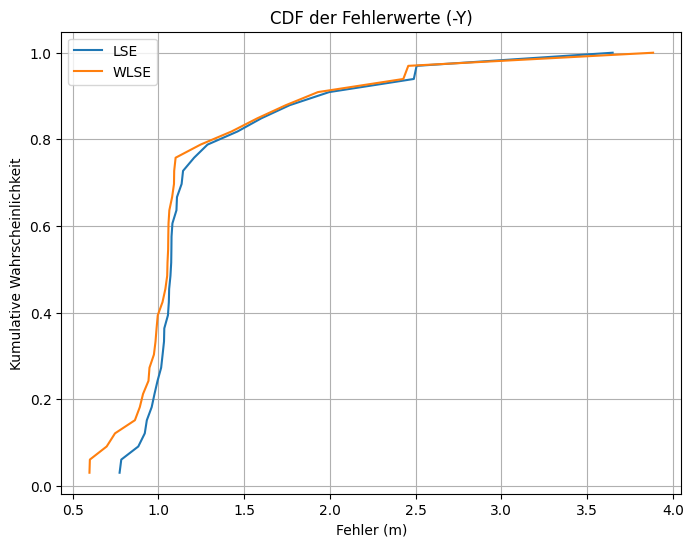

Benutzer in +Y Richtung


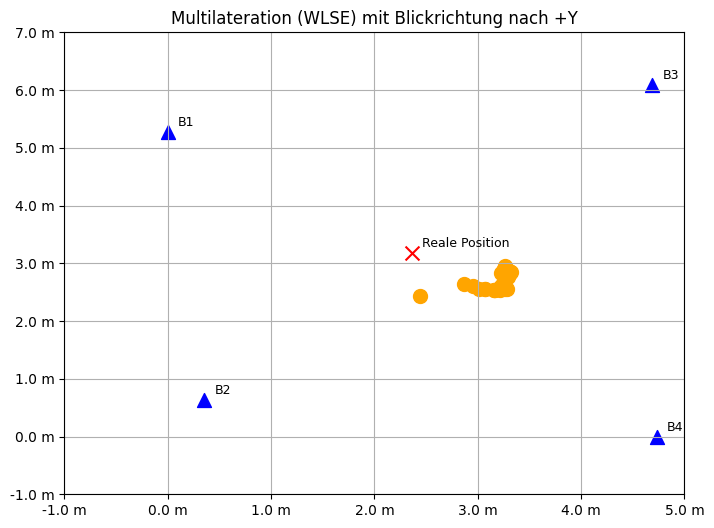

MSE for WLSE: 0.973 m


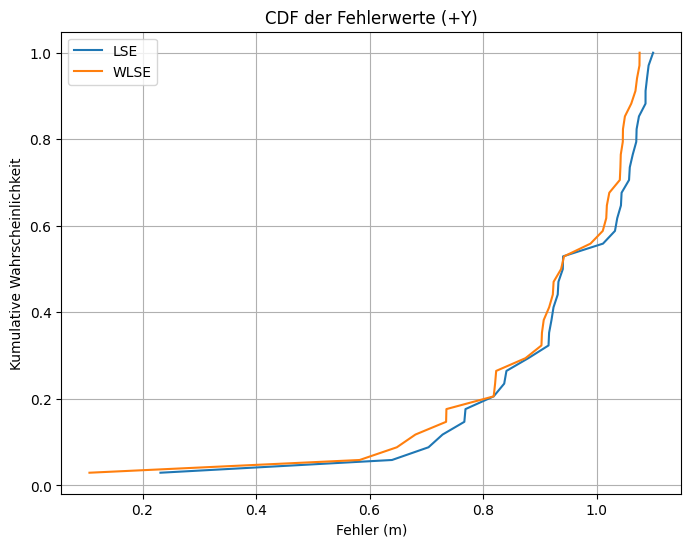

In [8]:
# Beacons definieren
beacon = [
    {'x': 0.00, 'y': 5.28, 'label': 'B1', 'group': 1},
    {'x': 0.35, 'y': 0.64, 'label': 'B2', 'group': 1},
    {'x': 4.69, 'y': 6.09, 'label': 'B3', 'group': 1},
    {'x': 4.73, 'y': 0.00, 'label': 'B4', 'group': 1},
]

# Referenzpunkte
ref1 = {'x': 3.38, 'y': 1.17, 'label': 'Reale Position', 'group': 3}
ref2 = {'x': 2.36, 'y': 3.18, 'label': 'Reale Position', 'group': 3}
ref3 = {'x': 0.66, 'y': 3.18, 'label': 'Reale Position', 'group': 3}
ref4 = {'x': 3.76, 'y': 4.86, 'label': 'Reale Position', 'group': 3}
beacon.append(ref2)

# Symbole und Farben definieren
group_symbols = {1: '^', 2: 'o', 3: 'x'}
group_colors = {1: 'blue', 2: 'orange', 3: 'red'}

# Excel-Datei einlesen und die Koordinaten korrekt extrahieren
def read_excel(file_path):
    df = pd.read_excel(file_path, header=None, names=["id", "x", "y", "err", "method"])
    df = df[df["x"].str.contains('x: ', na=False)]  # Entferne Zeilen mit B1-B4
    df['x'] = df['x'].str.replace(r'x: ', '', regex=True).astype(float)
    df['y'] = df['y'].str.replace(r'y: ', '', regex=True).astype(float)
    df["err"] = df["err"].str.replace(r'err: ', '', regex=True).astype(float)
    df["method"] = df["method"].str.strip()
    return df

# Mean Squared Error
def calculate_mse(data, method, reference):
    filtered_data = data[data['method'] == method]
    mse = np.mean((filtered_data['x'] - reference['x'])**2 + (filtered_data['y'] - reference['y'])**2)
    return mse

# Graphen plotten
def plot_graph(data, method, title, reference):
    plt.figure(figsize=(8, 6))

    # Beacons plotten
    for b in beacon:
        plt.scatter(b['x'], b['y'], label=b['label'], marker=group_symbols[b['group']], color=group_colors[b['group']], s=100)
        plt.text(b['x'] + 0.1, b['y'] + 0.1, b['label'], fontsize=9)

    # User-Punkte plotten (nur LSE oder WLSE)
    users = data[data["method"] == method]
    plt.scatter(users["x"], users["y"], marker=group_symbols[2], color=group_colors[2], s=100, label=f'User ({method})')

    # Mean Squared Error berechnen
    mse = calculate_mse(data, method, reference)

    # Achsen und Titel
    plt.xticks(plt.xticks()[0], [f"{tick} m" for tick in plt.xticks()[0]])
    plt.yticks(plt.yticks()[0], [f"{tick} m" for tick in plt.yticks()[0]])
    plt.title(title)
    plt.grid(True)
    plt.show()
    print(f"MSE for {method}: {mse:.3f} m")

# ERROR CDF
def plot_cdf(data, title):
    plt.figure(figsize=(8, 6))

    for method in ['LSE', 'WLSE']:
        errors = data[data["method"] == method]['err'].astype(float).values
        errors.sort()
        cdf = np.arange(1, len(errors) + 1) / len(errors)
        plt.plot(errors, cdf, label=method)

    plt.xlabel('Fehler (m)')
    plt.ylabel('Kumulative Wahrscheinlichkeit')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Dateien einlesen
file_paths = [
    '/content/drive/MyDrive/Colab Notebooks/T3001_-x_ref2.xlsx',
    '/content/drive/MyDrive/Colab Notebooks/T3001_+x_ref2.xlsx',
    '/content/drive/MyDrive/Colab Notebooks/T3001_-y_ref2.xlsx',
    '/content/drive/MyDrive/Colab Notebooks/T3001_+y_ref2.xlsx'
]

data_sets = [read_excel(fp) for fp in file_paths]
directions = ['-X', '+X', '-Y', '+Y']

for direction, data in zip(directions, data_sets):
    print(f"Benutzer in {direction} Richtung")
    plot_graph(data, "WLSE", f"Multilateration (WLSE) mit Blickrichtung nach {direction}", ref2)
    plot_cdf(data, f"CDF der Fehlerwerte ({direction})")